In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("/content/customer_segmentation_data.csv")

In [3]:
print(df.head())

   id  age  gender  income  spending_score  membership_years  \
0   1   38  Female   99342              90                 3   
1   2   21  Female   78852              60                 2   
2   3   60  Female  126573              30                 2   
3   4   40   Other   47099              74                 9   
4   5   65  Female  140621              21                 3   

   purchase_frequency preferred_category  last_purchase_amount  
0                  24          Groceries                113.53  
1                  42             Sports                 41.93  
2                  28           Clothing                424.36  
3                   5      Home & Garden                991.93  
4                  25        Electronics                347.08  


In [4]:
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])
df["preferred_category"] = le.fit_transform(df["preferred_category"])

In [5]:
X = df[["age","income","spending_score",
        "membership_years","purchase_frequency",
        "last_purchase_amount"]]

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

In [8]:
print(df[["id","income","spending_score","Cluster"]].head(10))

   id  income  spending_score  Cluster
0   1   99342              90        3
1   2   78852              60        3
2   3  126573              30        1
3   4   47099              74        0
4   5  140621              21        1
5   6   57305              24        1
6   7   54319              68        3
7   8  108115              94        2
8   9   34424              29        0
9  10   45839              55        0


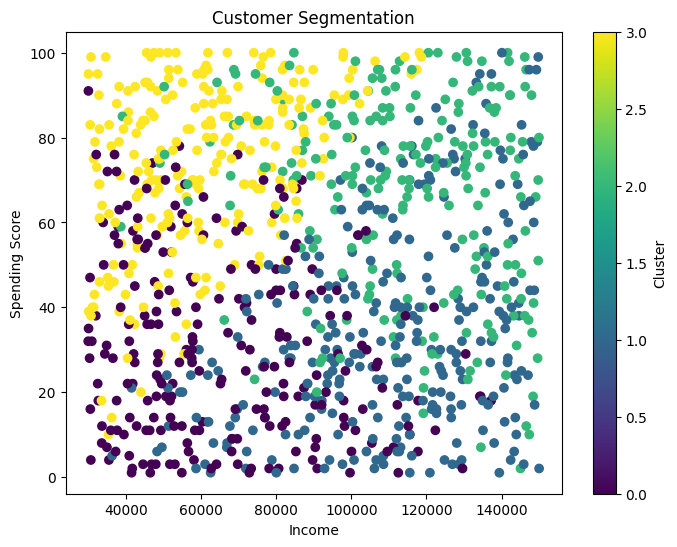

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(df["income"], df["spending_score"], c=df["Cluster"], cmap="viridis")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.colorbar(label="Cluster")
plt.show()

In [10]:
df.to_csv("Customer_Segmentation_Output.csv", index=False)

print("Completed Successfully!")

Completed Successfully!
